# Connectivity-based local structure comparison
Author: Shiyuan NIU

In [1]:
import scatlastb_utils as atl
help(atl.metrics.get_adjacency)
import anndata as ad
import scanpy as sc

adata_1 = ad.read_zarr("/vol/data/data/output/HRCA/RGC_scimilarity.zarr")
adata_2 = ad.read_zarr("/vol/data/data/output/HRCA/RGC.zarr")
#adata_3 = sc.read_h5ad("/home/ubuntu/sclecture_fm_benchmark/notebooks/retina_scgpt_cell_emb_finetuned_umap.h5ad") dataset for scGPT

print("obsp:", list(adata_1.obsp.keys()))
print("obsp:", list(adata_2.obsp.keys()))

/home/ubuntu/miniforge/envs/scanpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Help on function get_adjacency in module scatlastb_utils.metrics.knn_overlap:

get_adjacency(X, weighted: bool, k: int = 1, _lambda: float = 1, tol: float = 1e-05, use_dask: bool = False, chunk_size: int = 50000)
    Retrieve adjacency matrix from distances or connectivities.
    
    :param weighted: whether to preserve weighting of adjacency or return unweighted adjacency
        Default: weighted=False - 1 when edge present, 0 when edge not present
    :param k: power of matrix multiplication. Computationally expensive and densifies the matrix.
        Default: 1, no multiplication performed.



/home/ubuntu/miniforge/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


obsp: ['connectivities--metrics:scimilarity', 'distances--metrics:scimilarity']
obsp: ['connectivities--metrics:drvi_global', 'connectivities--metrics:drvi_lineage', 'connectivities--metrics:harmony_global', 'connectivities--metrics:harmony_lineage', 'connectivities--metrics:scpoli_global', 'connectivities--metrics:scpoli_lineage', 'connectivities--metrics:scvi_global', 'connectivities--metrics:scvi_lineage', 'distances--metrics:drvi_global', 'distances--metrics:drvi_lineage', 'distances--metrics:harmony_global', 'distances--metrics:harmony_lineage', 'distances--metrics:scpoli_global', 'distances--metrics:scpoli_lineage', 'distances--metrics:scvi_global', 'distances--metrics:scvi_lineage']


**Compare two embedding first**

In [2]:
X_scvi = adata_2.obsp["connectivities--metrics:scvi_global"]
X_har  = adata_2.obsp["connectivities--metrics:harmony_global"]
X_Sci = adata_1.obsp["connectivities--metrics:scimilarity"]

A = atl.metrics.get_adjacency(X_scvi, weighted=False, k=1)
B = atl.metrics.get_adjacency(X_har,  weighted=False, k=1)
C = atl.metrics.get_adjacency(X_Sci,  weighted=False, k=1)

In [3]:
import numpy as np

def dissimilarity(A, B, eps=1e-12):
    # Convert the Sparse matrix to the CSR format (Compressed Sparse Row)
    # Copy a matrix to avoid modifying the original object when you later change A.data
    A = A.tocsr().copy()
    B = B.tocsr().copy()

    # binaryzation: Set the values of all non-zero elements to 1
    # Only care about "whether there is an edge or not", not what the weight of the edge is
    A.data[:] = 1
    B.data[:] = 1

    # Calculate the size of the intersection of neighbors for each cell
    inter = np.asarray(A.multiply(B).getnnz(axis=1), dtype=float)
    dA = np.asarray(A.getnnz(axis=1), dtype=float)
    dB = np.asarray(B.getnnz(axis=1), dtype=float)

    # Jaccard
    union = dA + dB - inter
    sim = np.where(union > 0, inter / (union + eps), 0.0)

    # F1
    # denom = dA + dB
    # sim = np.where(denom > 0, 2 * inter / denom, 0.0)
    return 1 - sim

dissimilarity(A, C)

array([1.        , 1.        , 1.        , ..., 1.        , 1.        ,
       0.99029126], shape=(399605,))

# Global dataset

In [4]:
graphs = {
    "scimilarity": adata_1.obsp["connectivities--metrics:scimilarity"],
    "scvi_global": adata_2.obsp["connectivities--metrics:scvi_global"],
    "harmony_global": adata_2.obsp["connectivities--metrics:harmony_global"],
    "drvi_global": adata_2.obsp["connectivities--metrics:drvi_global"],
    "scpoli_global": adata_2.obsp["connectivities--metrics:scpoli_global"],
}

adj = {}

for name, G in graphs.items():
    adj[name] = atl.metrics.get_adjacency(G, weighted=False, k=1)

In [5]:
print(adata_1.n_obs, adata_2.n_obs)

399605 399605


In [6]:
print((adata_1.obs_names == adata_2.obs_names).all())

True


In [7]:
print(adj["scimilarity"].shape)

(399605, 399605)


In [8]:
dissim_results = {}
for name, G in graphs.items():
    if name == "scimilarity":
        continue
    vec = dissimilarity(graphs["scimilarity"], G)
    dissim_results[name] = vec
    adata_1.obs[f"dissim_scim_vs_{name}"] = vec

In [9]:
for name, vec in dissim_results.items():
    print(f"scimilarity vs {name}: mean dissimilarity = {vec.mean():.4f}")

scimilarity vs scvi_global: mean dissimilarity = 0.9965
scimilarity vs harmony_global: mean dissimilarity = 0.9969
scimilarity vs drvi_global: mean dissimilarity = 0.9973
scimilarity vs scpoli_global: mean dissimilarity = 0.9976


In [10]:
import pandas as pd
names = list(graphs.keys())
mean_dissim = pd.DataFrame(index=names, columns=names, dtype=float)

for n1 in names:
    for n2 in names:
        mean_dissim.loc[n1, n2] = dissimilarity(graphs[n1], graphs[n2]).mean()

mean_dissim

,scimilarity,scvi_global,harmony_global,drvi_global,scpoli_global
scimilarity,1.445232e-14,9.965120e-01,9.969237e-01,9.972709e-01,9.975711e-01
scvi_global,9.965120e-01,1.474724e-14,9.905966e-01,9.900711e-01,9.956431e-01
harmony_global,9.969237e-01,9.905966e-01,1.477528e-14,9.929665e-01,9.947967e-01
drvi_global,9.972709e-01,9.900711e-01,9.929665e-01,1.434318e-14,9.959404e-01
scpoli_global,9.975711e-01,9.956431e-01,9.947967e-01,9.959404e-01,1.482644e-14


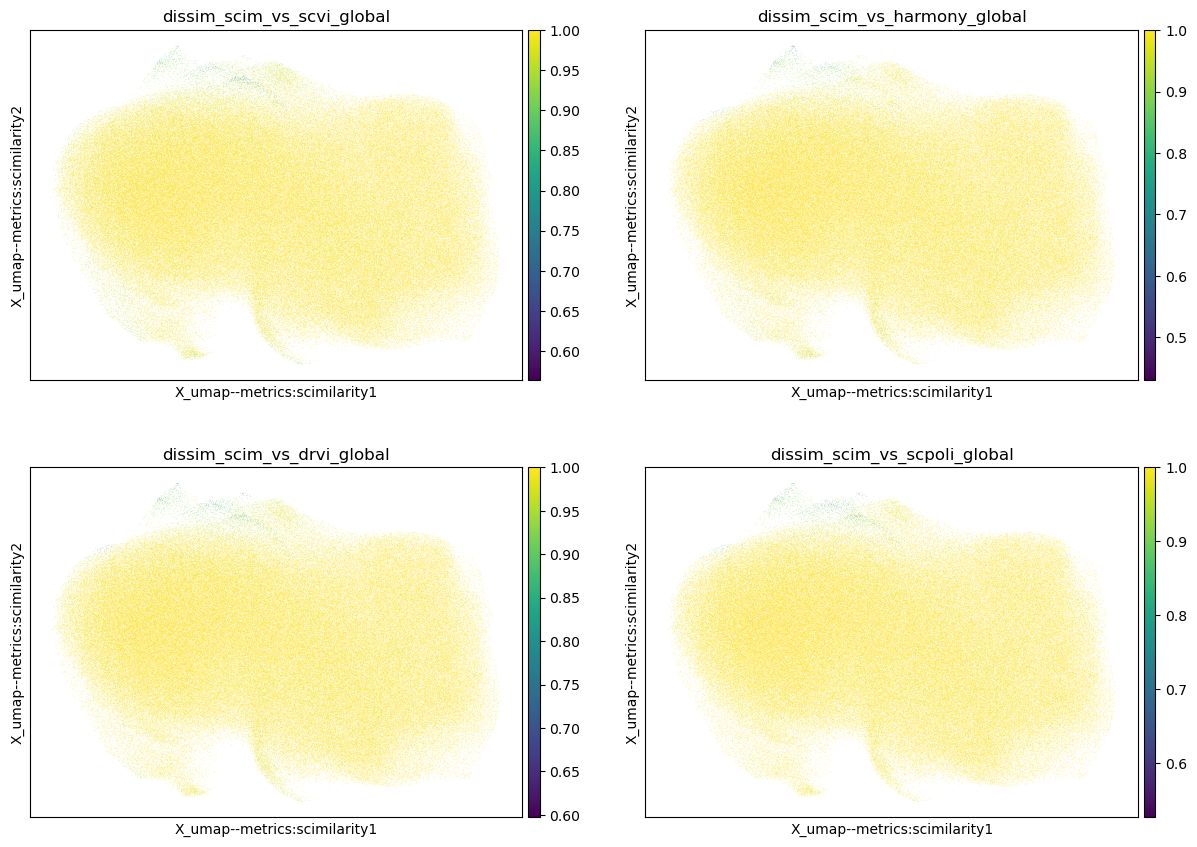

In [11]:
sc.pl.embedding(
    adata_1,
    basis="X_umap--metrics:scimilarity",
    color=[
        "dissim_scim_vs_scvi_global",
        "dissim_scim_vs_harmony_global",
        "dissim_scim_vs_drvi_global",
        "dissim_scim_vs_scpoli_global",
    ],
    ncols=2
)

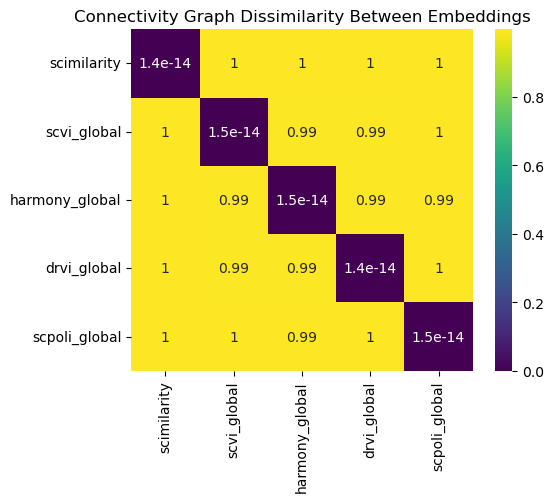

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    mean_dissim,
    annot=True,        
    cmap="viridis",    
    square=True
)

plt.title("Connectivity Graph Dissimilarity Between Embeddings")
plt.tight_layout()
plt.show()

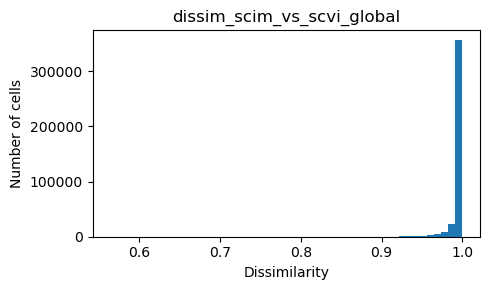

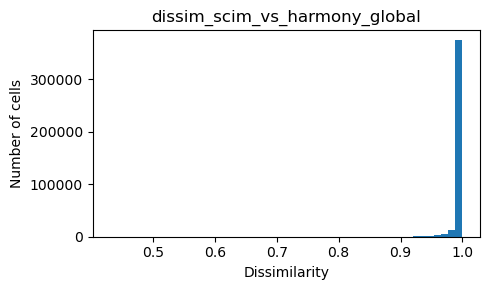

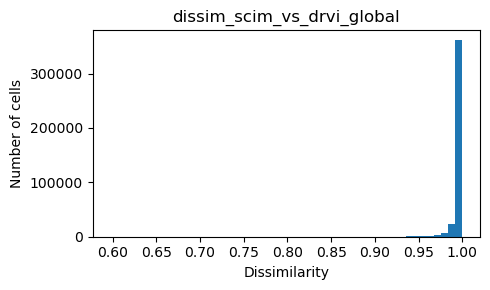

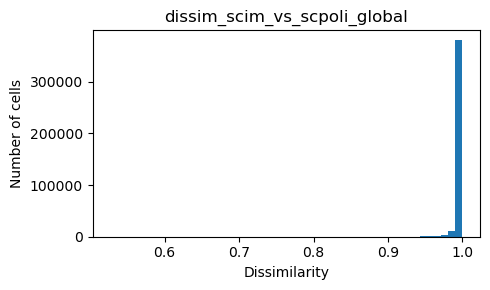

In [13]:
for col in [
    "dissim_scim_vs_scvi_global",
    "dissim_scim_vs_harmony_global",
    "dissim_scim_vs_drvi_global",
    "dissim_scim_vs_scpoli_global",
]:
    plt.figure(figsize=(5, 3))
    plt.hist(adata_1.obs[col], bins=50)
    plt.title(col)
    plt.xlabel("Dissimilarity")
    plt.ylabel("Number of cells")
    plt.tight_layout()
    plt.show()

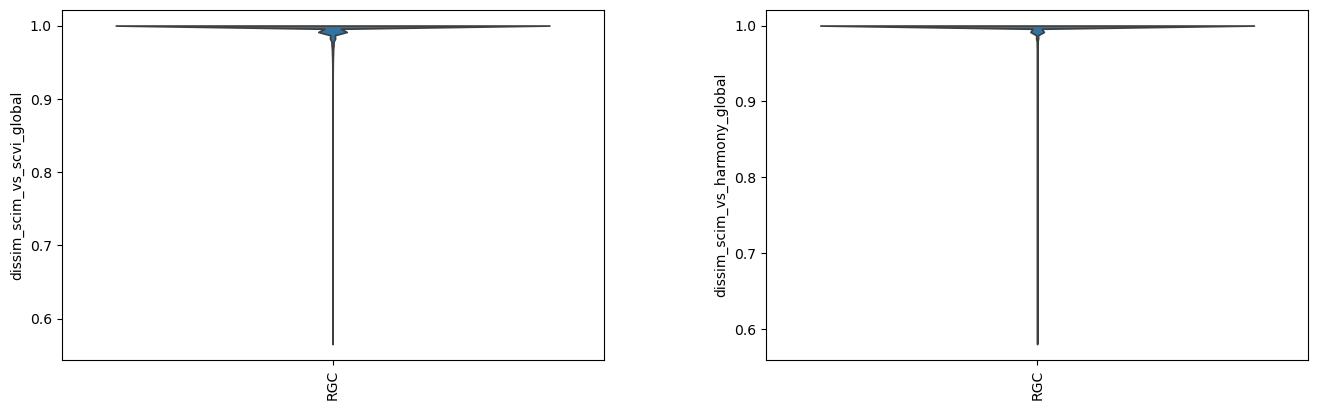

In [36]:
sc.pl.violin(
    adata_1,
    keys=[
        "dissim_scim_vs_scvi_global",
        "dissim_scim_vs_harmony_global",
    ],
    groupby="majorclass",
    rotation=90,
    stripplot=False
)

In [15]:
for name, G in graphs.items():
    print(name, "mean neighbors:", G.getnnz(axis=1).mean())

scimilarity mean neighbors: 75.20593586166339
scvi_global mean neighbors: 82.78298820084834
harmony_global mean neighbors: 86.66045720148647
drvi_global mean neighbors: 87.234624191389
scpoli_global mean neighbors: 69.74421240975464


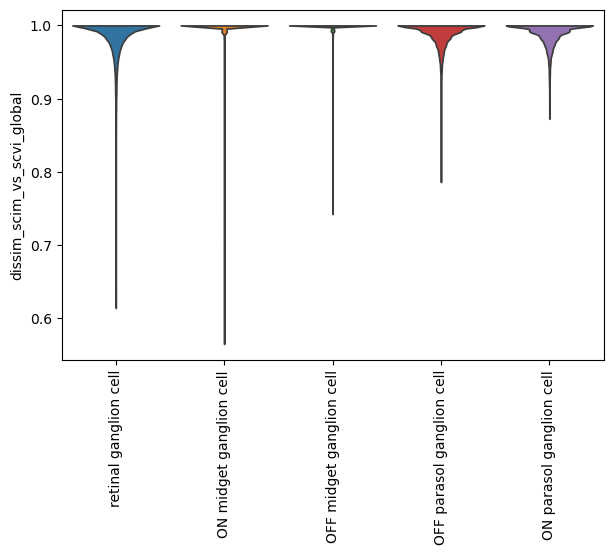

In [17]:
sc.pl.violin(
    adata_1,
    keys="dissim_scim_vs_scvi_global",
    groupby="cell_type",
    rotation=90,
    stripplot=False
)

# Lineage 

In [26]:
graphs_l = {
    "scimilarity": adata_1.obsp["connectivities--metrics:scimilarity"],
    "scvi_lineage": adata_2.obsp["connectivities--metrics:scvi_lineage"],
    "harmony_lineage": adata_2.obsp["connectivities--metrics:harmony_lineage"],
    "drvi_lineage": adata_2.obsp["connectivities--metrics:drvi_lineage"],
    "scpoli_lineage": adata_2.obsp["connectivities--metrics:scpoli_lineage"],
}

adj = {}

for name_l, G_l in graphs_l.items():
    adj[name_l] = atl.metrics.get_adjacency(G_l, weighted=False, k=1)

In [27]:
dissim_results_l = {}
for name_l, G_l in graphs_l.items():
    if name_l == "scimilarity":
        continue
    vec_l = dissimilarity(graphs["scimilarity"], G_l)
    dissim_results_l[name_l] = vec_l
    adata_1.obs[f"dissim_scim_vs_{name_l}"] = vec_l

In [28]:
for name_l, vec_l in dissim_results_l.items():
    print(f"scimilarity vs {name_l}: mean dissimilarity = {vec_l.mean():.4f}")

scimilarity vs scvi_lineage: mean dissimilarity = 0.9966
scimilarity vs harmony_lineage: mean dissimilarity = 0.9980
scimilarity vs drvi_lineage: mean dissimilarity = 0.9959
scimilarity vs scpoli_lineage: mean dissimilarity = 0.9955


In [29]:
import pandas as pd
names_l = list(graphs_l.keys())
mean_dissim_l = pd.DataFrame(index=names_l, columns=names_l, dtype=float)

for n1 in names_l:
    for n2 in names_l:
        mean_dissim_l.loc[n1, n2] = dissimilarity(graphs_l[n1], graphs_l[n2]).mean()

mean_dissim_l

,scimilarity,scvi_lineage,harmony_lineage,drvi_lineage,scpoli_lineage
scimilarity,1.445232e-14,9.966135e-01,9.980373e-01,9.958526e-01,9.955443e-01
scvi_lineage,9.966135e-01,1.507453e-14,9.821055e-01,9.767584e-01,9.881039e-01
harmony_lineage,9.980373e-01,9.821055e-01,1.492980e-14,9.890685e-01,9.898400e-01
drvi_lineage,9.958526e-01,9.767584e-01,9.890685e-01,1.495785e-14,9.825519e-01
scpoli_lineage,9.955443e-01,9.881039e-01,9.898400e-01,9.825519e-01,1.551480e-14


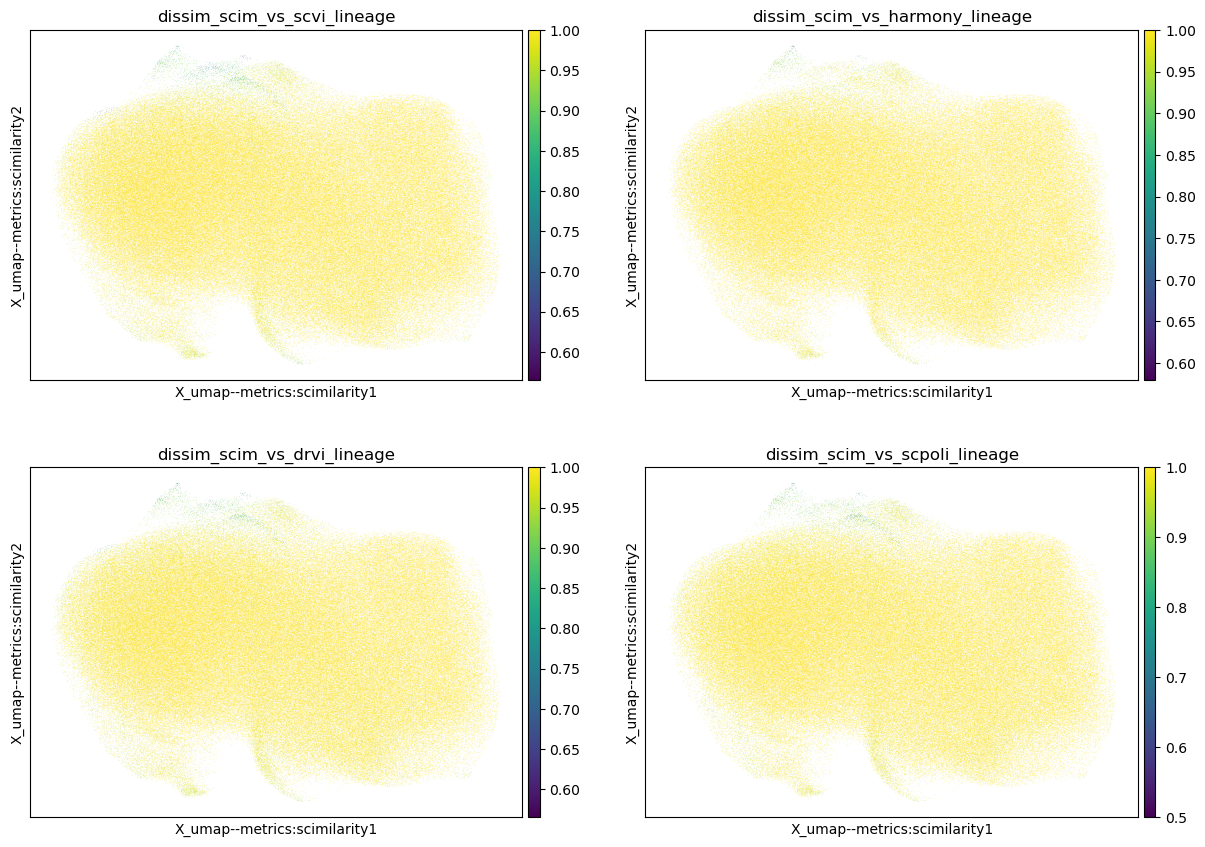

In [30]:
sc.pl.embedding(
    adata_1,
    basis="X_umap--metrics:scimilarity",
    color=[
        "dissim_scim_vs_scvi_lineage",
        "dissim_scim_vs_harmony_lineage",
        "dissim_scim_vs_drvi_lineage",
        "dissim_scim_vs_scpoli_lineage",
    ],
    ncols=2
)

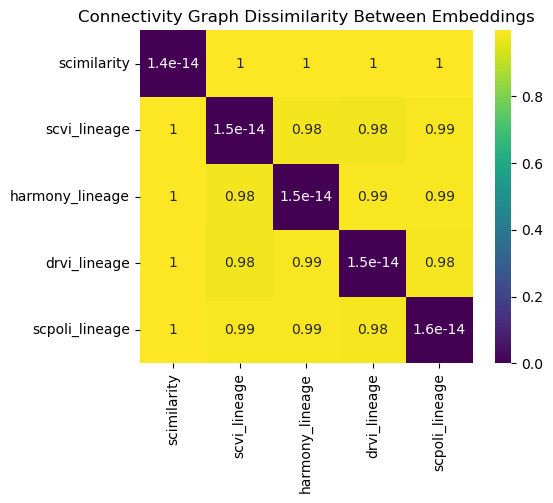

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    mean_dissim_l,
    annot=True,        
    cmap="viridis",    
    square=True
)

plt.title("Connectivity Graph Dissimilarity Between Embeddings")
plt.tight_layout()
plt.show()

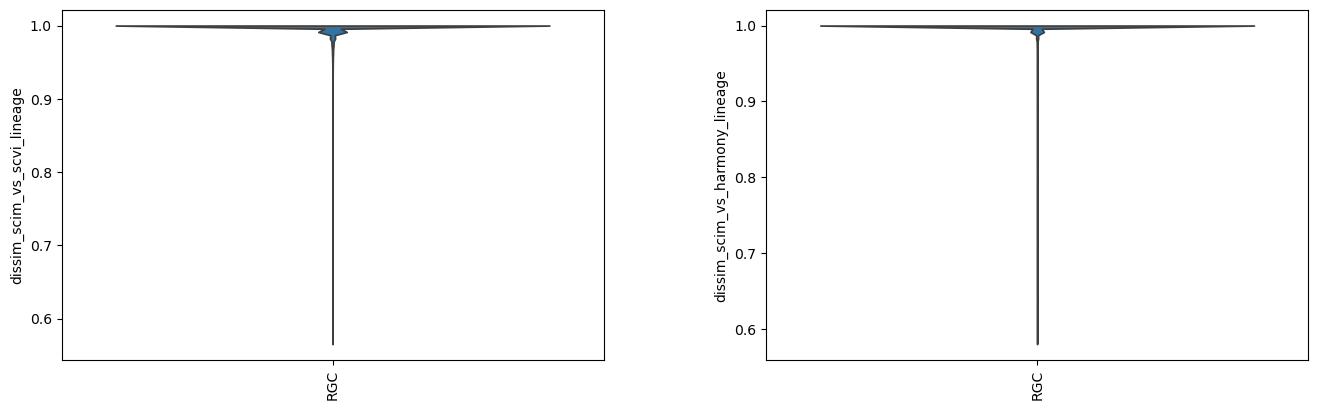

In [34]:
sc.pl.violin(
    adata_1,
    keys=[
        "dissim_scim_vs_scvi_lineage",
        "dissim_scim_vs_harmony_lineage",
    ],
    groupby="majorclass",
    rotation=90,
    stripplot=False
)

In [35]:
for name_l, G_l in graphs_l.items():
    print(name_l, "mean neighbors:", G_l.getnnz(axis=1).mean())

scimilarity mean neighbors: 75.20593586166339
scvi_lineage mean neighbors: 78.51654008333229
harmony_lineage mean neighbors: 87.45609789667296
drvi_lineage mean neighbors: 86.5546677343877
scpoli_lineage mean neighbors: 66.69394026601269


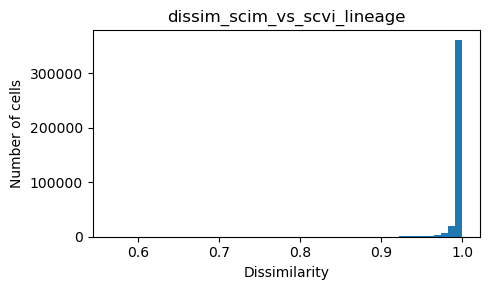

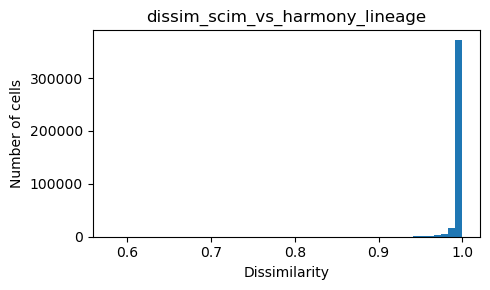

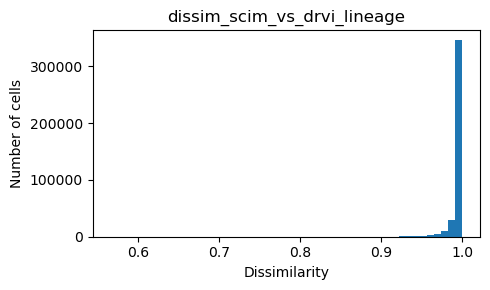

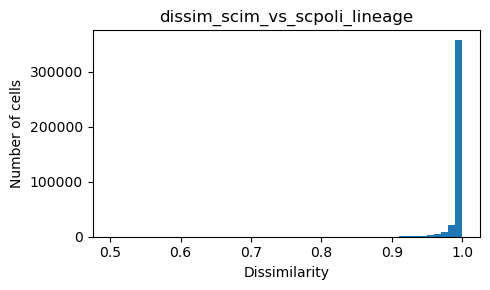

In [37]:
for col in [
    "dissim_scim_vs_scvi_lineage",
    "dissim_scim_vs_harmony_lineage",
    "dissim_scim_vs_drvi_lineage",
    "dissim_scim_vs_scpoli_lineage",
]:
    plt.figure(figsize=(5, 3))
    plt.hist(adata_1.obs[col], bins=50)
    plt.title(col)
    plt.xlabel("Dissimilarity")
    plt.ylabel("Number of cells")
    plt.tight_layout()
    plt.show()